In [1]:
%load_ext autoreload
%autoreload 2

In [14]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import stim
import time
import scipy as sp

from pygsti.extras.dem_construction import dem_tools as dems

from pygsti.modelmembers.operations import ExpErrorgenOp
from pygsti.baseobjs.statespace import QubitSpace
import pauli_twirled_tools as pt
import pygsti

In [15]:
def compute_outcome_distribution_from_dem(dem):
    """
    Compute the outcome distribution from a DEM using log and Hadamard transform.

    Parameters:
    - dem: a detector error model

    Returns: 
    - prob_estimate: array of 2^n probabilities, in increasing binary order
    """
    # Convert DEM to attenuations
    stim_dem_str = dems.format_dem_stim(dem, n_logical=0)
    stim_dem = stim.DetectorErrorModel(stim_dem_str)
    attenuations = np.zeros(2**stim_dem.num_detectors, dtype=float)
    all_bitstrings = np.array([[int(bit) for bit in format(n, f'0{stim_dem.num_detectors}b')]for n in range(2**stim_dem.num_detectors)])
    for event in stim_dem:
        prob = event.args_copy()[0]
        targets = [target.val for target in event.targets_copy()]
        event = [1 if (stim_dem.num_detectors-idx-1) in targets else 0 for idx in range(stim_dem.num_detectors)]    
        attenuation = -np.log(1-2*prob)
        attenuations += attenuation * (1-(-1)**np.dot(all_bitstrings, event))/2
    
    # Compute polarizations from attenuations
    polarizations = np.exp(-attenuations)
    polarizations[0] = 1

    # Compute probabilities from polarizations
    probabilities = sp.linalg.hadamard(2**stim_dem.num_detectors) @ polarizations / 2**stim_dem.num_detectors
    nds = stim_dem.num_detectors

    probs_dict = {str(bin(b)[2:]).zfill(nds)[::-1]:p for b,p in enumerate(probabilities)}
    return probs_dict

In [16]:
def entropy(dist):
    probs = np.array(list(dist.values()))
    # Filter out zero probabilities to avoid log(0)
    significant_probs = probs[probs > 1e-16]
    entropy = -np.sum(significant_probs * np.log2(significant_probs))
    return entropy

In [17]:
def max_dist(d1, d2, cutoff=None):
    #d2 is true
    all_keys = list(set(list(d1.keys())+list(d2.keys())))
    if cutoff is not None:
        diffs = [np.abs(d1[k]-d2[k]) if (k in d1 and k in d2 and d2[k]>cutoff) else (d1[k] if k in d1 else d2[k]) for k in all_keys]
    else:
        diffs = [np.abs(d1[k]-d2[k]) if (k in d1 and k in d2) else (d1[k] if k in d1 else d2[k]) for k in all_keys]
    max_diff = np.max(diffs)
    max_key = all_keys[np.argmax(diffs)]
    rel_dist= max_diff/d2[max_key]

    return max_diff


In [18]:
def max_rel_dist(d1, d2, cutoff=None):
    #d2 is true
    all_keys = list(set(list(d1.keys())+list(d2.keys())))
    if cutoff is not None:
        diffs = [np.abs(d1[k]-d2[k])/d2[k] if (k in d1 and k in d2 and d2[k]>cutoff) else (d1[k] if k in d1 else d2[k]) for k in all_keys]
    else:
        diffs = [np.abs(d1[k]-d2[k])/d2[k] if (k in d1 and k in d2) else (d1[k] if k in d1 else d2[k]) for k in all_keys]
    max_diff = np.max(diffs)
    max_key = all_keys[np.argmax(diffs)]
    rel_dist= max_diff/d2[max_key]

    return max_diff


In [19]:
def median_dist(d1, d2):
    all_keys = list(set(list(d1.keys())+list(d2.keys())))
    return np.median([np.abs(d1[k]-d2[k]) if k in d1 and k in d2 else (d1[k] if k in d1 else d2[k]) for k in all_keys])


In [20]:
def tvd(d1, d2):
    all_keys = list(set(list(d1.keys())+list(d2.keys())))
    return sum(np.abs(d1[k]-d2[k]) if k in d1 and k in d2 else (d1[k] if k in d1 else d2[k])for k in all_keys)

In [21]:
def to_dets(syndrome_stats, n_syndromes, n_rounds):
    dets = {}
    
    for key in syndrome_stats.keys():
        if len(key) != n_syndromes*n_rounds+1:
            raise ValueError("Invalid syndrome statistics")
        
        new_key = key[:n_syndromes]
        
        for i in range(n_syndromes, len(key) - 1):
            new_char = str(int(key[i]) ^ int(key[i - n_syndromes]))
            new_key += new_char
        new_key += key[-1]
        
        # Add the transformed key to the new dictionary
        dets[new_key] = syndrome_stats[key]
    
    return dets

# Single-model example

In [16]:
erate=0.004
i=0
with open(f'data/sweep_rounds_{rounds}_infidelity_{erate}_{i}.txt', 'rb') as f:
    result_dict = pickle.load(f)
f.close()

with open(f'data/sweep_rounds_{rounds}_infidelity_{erate}_{i}_pauli_twirled.txt', 'rb') as f:
    results = pickle.load(f)
f.close()

pt_probs = results[1]
est_probs = result_dict['est_probs']
true_probs = to_dets(result_dict['true_probs'], 8, rounds)

In [21]:
all_keys = list(set(list(est_probs.keys())+list(true_probs.keys())))
diffs = [np.log10(np.abs(est_probs[k]-true_probs[k])) if k in est_probs and k in true_probs else (est_probs[k] if k in est_probs else true_probs[k]) for k in all_keys]
rel_diffs = [np.log10(np.abs(est_probs[k]-true_probs[k])/true_probs[k]) for k in all_keys if true_probs[k]>1e-6]

In [22]:
high_keys = [k for k in list(set(list(est_probs.keys())+list(true_probs.keys()))) if true_probs[k]>1e-10 and true_probs[k]<0.8]
high_values = [est_probs[k] for k in high_keys]
diffs = [np.log10(np.abs(est_probs[k]-true_probs[k])) if k in est_probs and k in true_probs else (est_probs[k] if k in est_probs else true_probs[k]) for k in high_keys]
rel_diffs = [np.log10(np.abs(est_probs[k]-true_probs[k])/true_probs[k]) for k in high_keys]

(array([  2.,  33., 202., 563., 497., 245., 124.,  69.,  21.,  16.]),
 array([-13.92929915, -12.94672157, -11.964144  , -10.98156642,
         -9.99898884,  -9.01641126,  -8.03383368,  -7.0512561 ,
         -6.06867852,  -5.08610094,  -4.10352336]),
 <BarContainer object of 10 artists>)

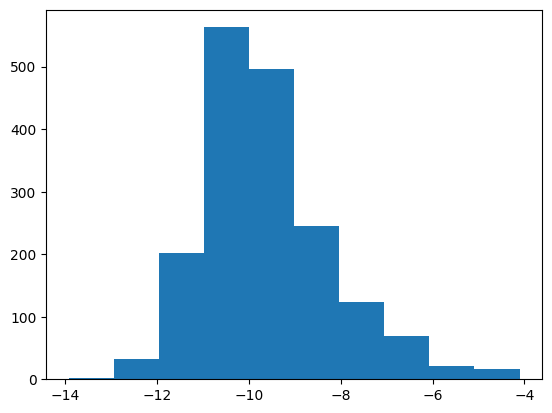

In [24]:
plt.hist(diffs)

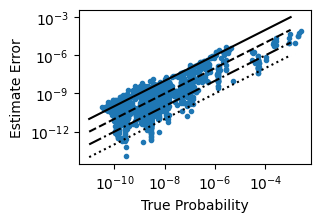

In [26]:
plt.figure(figsize=(3,2))
plt.scatter(high_values, diffs, marker='.')
xs = np.linspace(1e-11, 1e-3, 5)
plt.plot(xs,xs, color='black')
plt.plot(xs, [0.1*x for x in xs], color='black', linestyle='--')
plt.plot(xs, [0.01*x for x in xs], color='black', linestyle='-.')
plt.plot(xs, [0.001*x for x in xs], color='black', linestyle=':')
#plt.xlim(0.5e-10, 1e-3)
#plt.ylim(0.8e-13, 1e-5)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('True Probability')
plt.ylabel('Estimate Error')
plt.savefig(f'plots/h_error_{rounds}_example_{run}.pdf')

# Parameter sweep data

In [23]:
erates = np.linspace(0.002, 0.02, num=11)
erates = np.append(erates,[0.001,0.003])
run = 0
n_models = 10
rounds = 2
max_dists = []
max_rel_dists = []
median_dists = []
tvds = []
pt_tvds = []
entropies = []
infs = []
for erate in erates:
    for i in range(n_models):
        with open(f'data/sweep_rounds_{rounds}_infidelity_{erate}_{i}.txt', 'rb') as f:
            result_dict = pickle.load(f)
        f.close()
        
        est_probs = result_dict['est_probs']
        true_probs = to_dets(result_dict['true_probs'], 8, rounds)

        with open(f'data/sweep_rounds_{rounds}_infidelity_{erate}_{i}_pauli_twirled.txt', 'rb') as f:
            results = pickle.load(f)
        f.close()

        print(erate, i)
        
        pt_probs = results[1]
        pt_tvds.append(tvd(pt_probs, true_probs))

        median_dists.append(median_dist(est_probs, true_probs))
        tvds.append(tvd(est_probs, true_probs))
        entropies.append(entropy(true_probs))
        infs.append(result_dict['generator_infidelity'])



0.002 0
0.002 1
0.0038000000000000004 0
0.0038000000000000004 1
0.005600000000000001 0
0.005600000000000001 1
0.0074 0
0.0074 1
0.0092 0
0.0092 1
0.011000000000000001 0
0.011000000000000001 1
0.0128 0
0.0128 1
0.014600000000000002 0
0.014600000000000002 1
0.0164 0
0.0164 1
0.0182 0
0.0182 1
0.02 0
0.02 1
0.001 0
0.001 1
0.003 0
0.003 1


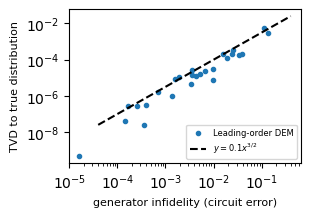

In [24]:
plt.figure(figsize=(3,2))
plt.scatter(infs, tvds, marker='.',label='Leading-order DEM')
plt.scatter(infs, pt_tvds, marker='.', label='Pauli twirled model')
#xs = np.linspace(0.4e-4, 4e-1)
ys = xs**(3/2)/10
plt.plot(xs,ys,linestyle='--', color='black', label=r'''$y=0.1x^{3/2}$''')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='lower right',fontsize=6)
plt.xlabel('generator infidelity (circuit error)', fontsize=8)
plt.ylabel('TVD to true distribution', fontsize=8)
#plt.savefig(f'plots/h_error_{rounds}_tvd_w_pt.pdf')
plt.show()

In [ ]:
plt.figure(figsize=(3,2))
plt.scatter(infs, [t/inf**(3/2) for t, inf in zip(tvds,infs)],marker='.')
plt.scatter(infs, [t/inf**(3/2) for t, inf in zip(pt_tvds,infs)],marker='.')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='lower right',fontsize=6)
plt.xlabel('generator infidelity (circuit error)', fontsize=8)
plt.ylabel(r'''TVD/$\epsilon_{circ}^{3/2}$''', fontsize=8)
plt.savefig(f'plots/h_error_{rounds}_tvd_w_pt_scaling.pdf')